# BPS5231 AI for Sustainable Building Design L8

# KMeans on Real Buildings

Goal: cluster buildings by Site EUI, GFA, Year Built, GHG and see patterns by Primary Property Type.

Knobs: K_CLUSTERS (2–8).

Visuals: elbow & silhouette, PCA 2-D scatter, cluster centroids (original units), and per-cluster property-type bars.

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.rcParams.update({"figure.figsize": (6,4)})

In [ ]:
# Current LL84 dataset (2022–present)
URL = "https://data.cityofnewyork.us/resource/5zyy-y8am.csv?$limit=20000"

def load_ll84(url):
    try:
        return pd.read_csv(url)
    except Exception as e:
        print("Remote load failed:", e)
        return None

df_raw = load_ll84(URL)

# Fallback tiny sample so the notebook always runs
if df_raw is None or df_raw.empty:
    print("Using fallback sample.")
    csv_fallback = """type,gfa_ft2,year,site_eui,wn_site_eui,ghg_tco2e
Office,350000,1985,62,58,4200
Multifamily Housing,120000,1962,48,50,1500
K-12 School,90000,2001,36,34,600
Retail Store,70000,1995,72,69,980
Hospital (General Medical & Surgical),600000,1978,95,91,12000
Hotel,250000,2010,68,65,3200
Other,150000,1931,80,78,2100
"""
    df_raw = pd.read_csv(io.StringIO(csv_fallback))

# --- map varying column names to a common schema if present ---
def pick(candidates, cols):
    for c in candidates:
        if c in cols: return c
    return None

cols_available = set(df_raw.columns)

MAP = {
    # property type
    "type": pick([
        "primary_property_type_self_selected",
        "primary_property_type_-_self-selected",
        "self-reported_primary_property_type",
        "primary_property_type_-_portfolio_manager",
        "primary_property_type",
        "property_type",
        "type"
    ], cols_available),

    # gross floor area (ft²)
    "gfa_ft2": pick([
        "property_gfa_self_reported_ft2",
        "property_gfa_-_self-reported_ft2",
        "property_gfa_self_reported_ft",
        "property_gfa_-_self-reported_ft",
        "gross_floor_area_building_s__ft_",
        "reported_gross_floor_area_ft2",
        "property_gfa__ft_",
        "gfa_ft2"
    ], cols_available),

    # year built
    "year": pick([
        "year_built",
        "built",
        "year",
        "year_of_construction"
    ], cols_available),

    # site EUI (kBtu/ft²)
    "site_eui": pick([
        "site_eui_kbtu_ft2",
        "site_eui__k_btu_ft__",
        "site_eui_kbtu_ft",
        "site_eui__k_btu_ft2_",
        "site_eui"
    ], cols_available),

    # weather-normalized site EUI (kBtu/ft²)
    "wn_site_eui": pick([
        "weather_normalized_site_eui_kbtu_ft2",
        "weather_normalized_site_eui__k_btu_ft__",
        "weather_normalized_site_eui_kbtu_ft",
        "weather_normalized_site_eui"
    ], cols_available),

    # total GHG emissions (tCO2e)
    "ghg_tco2e": pick([
        "total_ghg_emissions_metric_tons_co2e",
        "total_ghg_emissions_mtco2e",
        "ghg_emissions_metric_tons_co2e",
        "total_ghg_emissions_tco2e",
        "ghg_tco2e"
    ], cols_available),
}

keep = {k:v for k,v in MAP.items() if v is not None}
df = df_raw[list(keep.values())].copy()
df.columns = list(keep.keys())

# coerce numerics where applicable
for c in ["gfa_ft2","year","site_eui","wn_site_eui","ghg_tco2e"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# basic cleaning that tolerates missing columns
if "gfa_ft2" in df: df = df[(df["gfa_ft2"]>1e3) & (df["gfa_ft2"]<5e7)]
if "year" in df:    df = df[(df["year"]>1800) & (df["year"]<=2025)]
if "site_eui" in df:    df = df[(df["site_eui"]>0) & (df["site_eui"]<1500)]
if "wn_site_eui" in df: df = df[(df["wn_site_eui"]>0) & (df["wn_site_eui"]<1500)]
if "ghg_tco2e" in df:   df = df[(df["ghg_tco2e"]>=0)]

df = df.dropna().reset_index(drop=True)

# collapse long tail of property types for plots
if "type" in df:
    top_types = df["type"].value_counts().head(10).index
    df["type10"] = df["type"].where(df["type"].isin(top_types), "Other")

print("Final columns:", list(df.columns))
print("Shape after cleaning:", df.shape)
df.head(3)


/tmp/ipython-input-785559631.py:6: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(url)


Final columns: ['type', 'year', 'site_eui', 'wn_site_eui', 'type10']
Shape after cleaning: (18226, 5)


,type,year,site_eui,wn_site_eui,type10
0,Non-Refrigerated Warehouse,1930,10.1,10.6,Non-Refrigerated Warehouse
1,Multifamily Housing,1960,58.5,58.5,Multifamily Housing
2,Mixed Use Property,1941,63.8,64.1,Mixed Use Property


Site EUI = actual energy used at the building site per floor area during the reporting year.
Units: kBtu/ft²·yr (or MJ/m²·yr). It reflects the weather that actually happened that year.

Weather-Normalized Site EUI (wn_site_eui) = the same metric adjusted to a typical/weather-normal year (EPA Portfolio Manager does this).
Idea: remove hot/cold year effects so you can compare buildings—or the same building year-over-year—on a fairer basis.

In [ ]:
# Candidate numeric features in order of preference
CANDIDATES = ["site_eui", "wn_site_eui", "gfa_ft2", "year", "ghg_tco2e"]

features = [c for c in CANDIDATES if c in df.columns]
if len(features) < 2:
    # ensure at least 2 dims for PCA scatter & k-means stability
    # if only 1 present, duplicate with noise (rare with fallback)
    only = features[0] if features else None
    raise ValueError(f"Not enough numeric features found. Present: {features}. "
                     "Consider re-running or using the fallback sample.")

X = df[features].copy()

# log-transform skewed positives, if present
for c in ["gfa_ft2", "ghg_tco2e"]:
    if c in X.columns:
        X[c] = np.log1p(X[c])

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

print("Using features:", features)


Using features: ['site_eui', 'wn_site_eui', 'year']


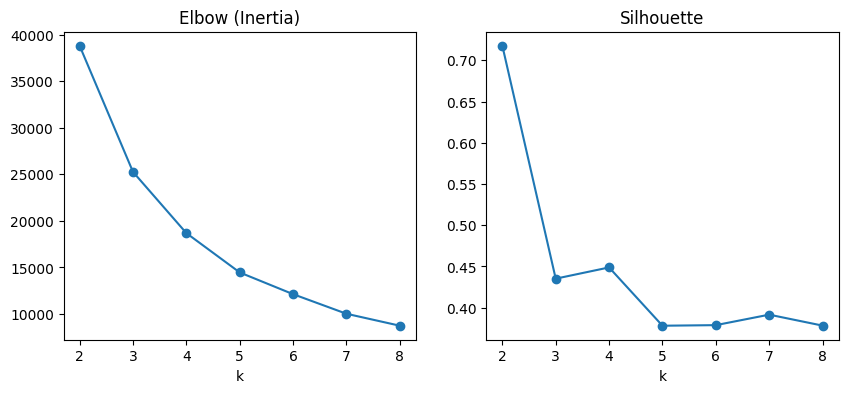

In [ ]:
K_MIN, K_MAX = 2, 8
inertias, sils = [], []
for k in range(K_MIN, K_MAX+1):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xz)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xz, km.labels_))

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(range(K_MIN,K_MAX+1), inertias, marker="o"); ax[0].set_title("Elbow (Inertia)"); ax[0].set_xlabel("k")
ax[1].plot(range(K_MIN,K_MAX+1), sils, marker="o");    ax[1].set_title("Silhouette");       ax[1].set_xlabel("k")
plt.show()

In [ ]:
K_CLUSTERS = 4  # try 3..6 after checking plots
kmeans = KMeans(n_clusters=K_CLUSTERS, n_init=10, random_state=42)
labels = kmeans.fit_predict(Xz)

df["cluster"] = labels
df["cluster"].value_counts().sort_index()

,count
cluster,
0,1419
1,11360
2,5372
3,75


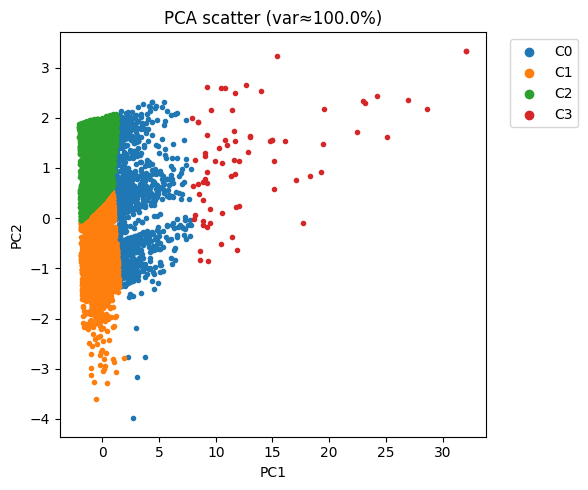

In [ ]:
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(Xz)
expl = pca.explained_variance_ratio_.sum()*100

plt.figure(figsize=(6,5))
for c in range(K_CLUSTERS):
    m = (labels==c)
    plt.scatter(X2[m,0], X2[m,1], s=9, label=f"C{c}")
plt.title(f"PCA scatter (var≈{expl:.1f}%)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(markerscale=2, bbox_to_anchor=(1.04,1), loc="upper left")
plt.tight_layout(); plt.show()

In [ ]:
centers_z = kmeans.cluster_centers_
centers = pd.DataFrame(scaler.inverse_transform(centers_z), columns=features)

# undo logs if we applied them
if "gfa_ft2" in centers.columns:  centers["gfa_ft2"]  = np.expm1(centers["gfa_ft2"]).round()
if "ghg_tco2e" in centers.columns: centers["ghg_tco2e"] = np.expm1(centers["ghg_tco2e"]).round(2)

centers.index = [f"C{c}" for c in range(K_CLUSTERS)]
centers.round(2)

,site_eui,wn_site_eui,year
C0,181.66,183.69,1950.23
C1,72.41,73.60,1930.49
C2,59.91,60.55,1995.56
C3,636.35,639.93,1957.00


type10,Hotel,K-12 School,Manufacturing/Industrial Plant,Mixed Use Property,Multifamily Housing,Non-Refrigerated Warehouse,Office,Other,Residence Hall/Dormitory,Retail Store,Self-Storage Facility
cluster,,,,,,,,,,,
0,0.048,0.013,0.013,0.026,0.541,0.006,0.053,0.280,0.003,0.016,0.001
1,0.013,0.013,0.012,0.007,0.757,0.014,0.112,0.049,0.009,0.009,0.006
2,0.047,0.022,0.012,0.009,0.672,0.025,0.076,0.091,0.008,0.017,0.021
3,0.013,0.000,0.093,0.013,0.280,0.027,0.080,0.467,0.013,0.013,0.000


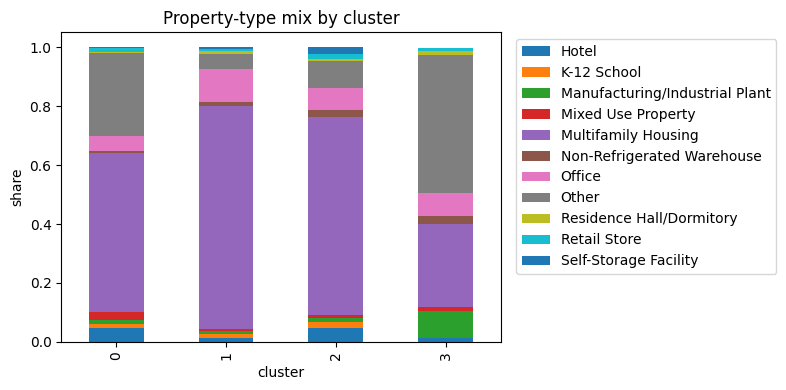

In [ ]:
if "type10" in df.columns:
    mix = pd.crosstab(df["cluster"], df["type10"], normalize="index").round(3)
    display(mix)
    ax = mix.plot(kind="bar", stacked=True, figsize=(8,4))
    ax.set_ylabel("share"); ax.set_title("Property-type mix by cluster")
    plt.legend(bbox_to_anchor=(1.02,1), loc="upper left"); plt.tight_layout(); plt.show()
else:
    print("Property type not available in this pull; skipping mix plot.")

# Hierarchical Clustering for Buildings

We’ll cluster buildings by Site EUI, floor area, year built, and GHG.

Knobs: N_CLUSTERS, N_SAMPLE_DENDRO.

Visuals: dendrogram (sampled), PCA scatter by cluster, clustered heatmap, and per-cluster profiles.

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list

np.random.seed(42)
plt.rcParams.update({"figure.figsize": (6,4), "axes.grid": True, "font.size": 11})

In [ ]:
# Synthetic buildings: property type + (gfa, year, site_eui, ghg) with realistic patterns
def make_buildings(n=1200):
    types = ["Office","Multifamily","K-12","Hospital","Retail","Hotel"]
    mix   = [0.25, 0.30, 0.12, 0.08, 0.15, 0.10]  # class proportions
    N = [int(n*p) for p in mix]; N[-1] = n - sum(N[:-1])

    rows = []
    for t, m in zip(types, N):
        if t=="Office":
            gfa  = np.random.lognormal(mean=np.log(1.8e5), sigma=0.6, size=m)   # ft²
            year = np.random.choice(range(1965, 2023), size=m, p=np.ones(58)/58)
            eui  = np.random.normal(60, 12, m) - 0.02*(year-1990)
        elif t=="Multifamily":
            gfa  = np.random.lognormal(np.log(9e4), 0.6, m)
            year = np.random.choice(range(1940, 2023), size=m)
            eui  = np.random.normal(45, 10, m) - 0.01*(year-1990)
        elif t=="K-12":
            gfa  = np.random.lognormal(np.log(7e4), 0.5, m)
            year = np.random.choice(range(1970, 2023), size=m)
            eui  = np.random.normal(35, 8, m) - 0.02*(year-2000)
        elif t=="Hospital":
            gfa  = np.random.lognormal(np.log(3.2e5), 0.5, m)
            year = np.random.choice(range(1950, 2023), size=m)
            eui  = np.random.normal(95, 15, m) - 0.01*(year-1990)
        elif t=="Retail":
            gfa  = np.random.lognormal(np.log(6e4), 0.7, m)
            year = np.random.choice(range(1960, 2023), size=m)
            eui  = np.random.normal(70, 14, m) - 0.015*(year-1990)
        elif t=="Hotel":
            gfa  = np.random.lognormal(np.log(1.2e5), 0.6, m)
            year = np.random.choice(range(1975, 2023), size=m)
            eui  = np.random.normal(65, 12, m) - 0.015*(year-2000)

        eui  = np.clip(eui, 15, 160)
        # Rough ghg proxy: scale with size * eui (compressed with log later)
        ghg  = 1.2e-5 * gfa * eui * np.random.lognormal(0, 0.15, m)

        part = pd.DataFrame({
            "type": t, "gfa_ft2": gfa, "year": year,
            "site_eui": eui, "ghg_tco2e": ghg
        })
        rows.append(part)

    df = pd.concat(rows, ignore_index=True)
    # light cleanup
    df = df[(df["site_eui"]>10) & (df["site_eui"]<200)]
    df = df[(df["gfa_ft2"]>2e3) & (df["gfa_ft2"]<1e7)]
    df = df[(df["year"]>=1940)]
    df = df.reset_index(drop=True)
    return df

df = make_buildings(1200)
df.head()

,type,gfa_ft2,year,site_eui,ghg_tco2e
0,Office,242496.030870,1981,40.147137,108.104091
1,Office,165670.068295,1975,66.820322,164.113624
2,Office,265488.088097,2008,51.688515,232.477087
3,Office,448888.606590,2011,66.427184,338.866669
4,Office,156407.507059,2022,50.200890,88.130932


In [ ]:
# Features for clustering (numeric)
features = ["site_eui", "gfa_ft2", "year", "ghg_tco2e"]
X = df[features].copy()

# Log-transform skewed positives
X["gfa_ft2"]   = np.log1p(X["gfa_ft2"])
X["ghg_tco2e"] = np.log1p(X["ghg_tco2e"])

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

print("Using features:", features, "| Std shape:", Xz.shape)

Using features: ['site_eui', 'gfa_ft2', 'year', 'ghg_tco2e'] | Std shape: (1200, 4)


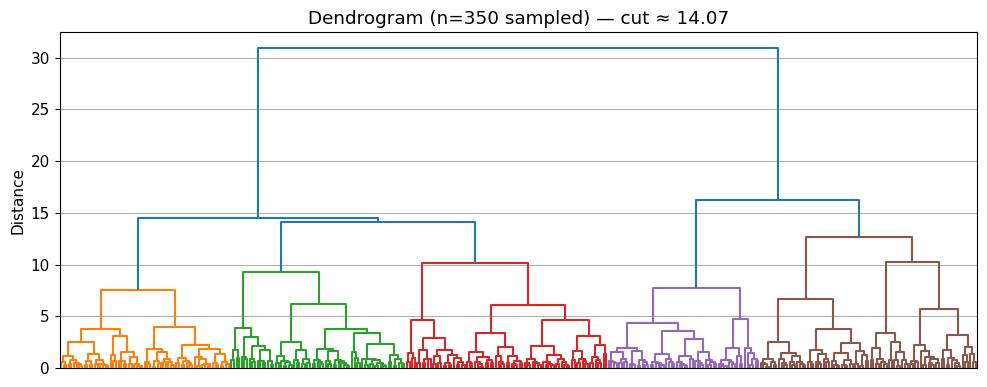

In [ ]:
# === student knobs ===
N_CLUSTERS      = 4     # try 3..6
N_SAMPLE_DENDRO = 350   # 150–500 keeps the dendrogram readable

# Sample a subset for the dendrogram (visual only)
idx_sub = np.random.choice(len(Xz), size=min(N_SAMPLE_DENDRO, len(Xz)), replace=False)
Xz_sub  = Xz[idx_sub]

# Ward linkage pairs best with Euclidean on standardized continuous data
Z = linkage(Xz_sub, method="ward")

# Compute a color threshold that yields ~N_CLUSTERS on the sampled tree
# (Use the distances at merges; pick a cut between the last (k) and (k-1) merges)
merge_dists = Z[:,2]
# distance at which there are N_CLUSTERS clusters:
if N_CLUSTERS >= 2 and N_CLUSTERS <= len(Xz_sub):
    # index of the cut between merges
    cut_idx = -N_CLUSTERS
    thr = merge_dists[cut_idx] if abs(cut_idx) < len(merge_dists) else merge_dists.mean()
else:
    thr = np.percentile(merge_dists, 75)

plt.figure(figsize=(10,4))
dendrogram(Z, no_labels=True, color_threshold=thr)
plt.title(f"Dendrogram (n={len(Xz_sub)} sampled) — cut ≈ {thr:.2f}")
plt.ylabel("Distance")
plt.tight_layout(); plt.show()

In [ ]:
agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage="ward", metric="euclidean")
labels = agg.fit_predict(Xz)
df["cluster_hc"] = labels

sil = silhouette_score(Xz, labels) if len(np.unique(labels))>1 else np.nan
print("Cluster sizes:", pd.Series(labels).value_counts().sort_index().to_dict())
print(f"Silhouette score: {sil:.3f}")

Cluster sizes: {0: 418, 1: 215, 2: 244, 3: 323}
Silhouette score: 0.195


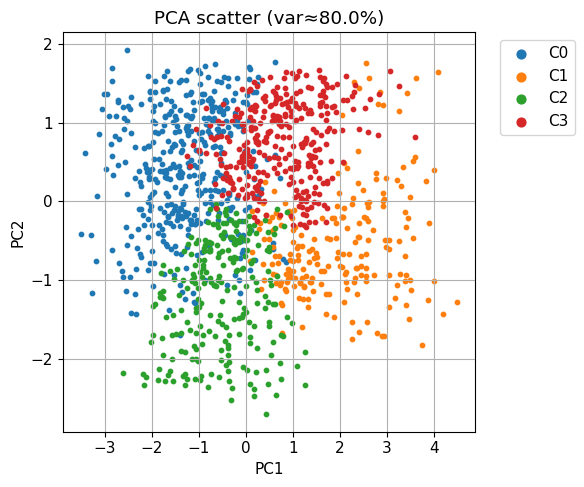

In [ ]:
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(Xz)
var2 = pca.explained_variance_ratio_.sum()*100

plt.figure(figsize=(6,5))
for c in range(N_CLUSTERS):
    m = (labels==c)
    plt.scatter(X2[m,0], X2[m,1], s=10, label=f"C{c}")
plt.title(f"PCA scatter (var≈{var2:.1f}%)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(markerscale=2, bbox_to_anchor=(1.04,1), loc="upper left")
plt.tight_layout(); plt.show()

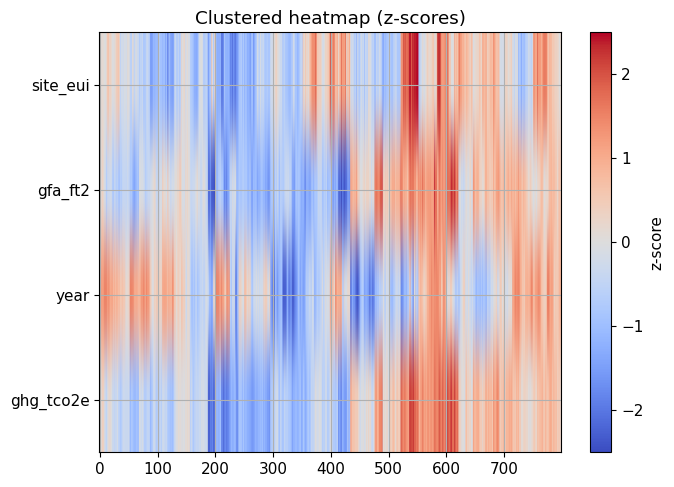

In [ ]:
# Order a manageable subset by dendrogram leaves for a blocky heatmap
n_heat = min(800, len(Xz))
idx_h  = np.random.RandomState(0).choice(len(Xz), size=n_heat, replace=False)
Z_h    = linkage(Xz[idx_h], method="ward")
leaf   = leaves_list(Z_h)

X_block   = Xz[idx_h][leaf]               # [n_heat, p]
labs_block= labels[idx_h][leaf]

plt.figure(figsize=(7,5))
plt.imshow(X_block.T, aspect="auto", cmap="coolwarm", vmin=-2.5, vmax=2.5)
plt.yticks(range(len(features)), features)
plt.title("Clustered heatmap (z-scores)")
plt.colorbar(label="z-score")
plt.tight_layout(); plt.show()

,site_eui,gfa_ft2,year,ghg_tco2e
C0,47.1,57095.0,1998.0,31.9
C1,71.2,267798.6,1976.0,237.5
C2,45.5,100768.8,1967.0,55.5
C3,59.3,171862.7,2006.0,120.5


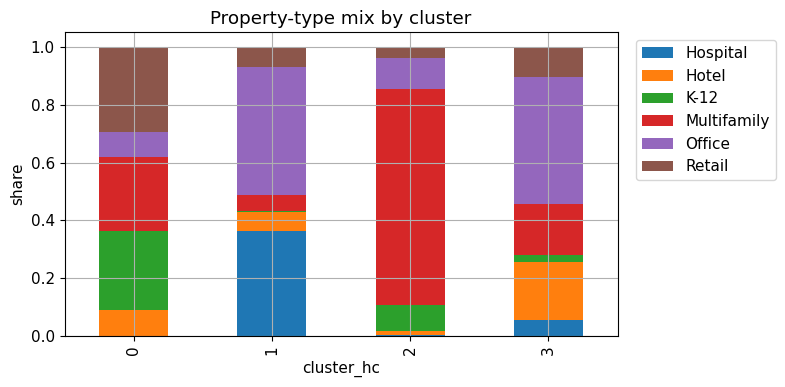

In [ ]:
# Centroid (median) per cluster in original units
inv = pd.DataFrame(scaler.inverse_transform(Xz), columns=features)
inv["cluster"] = labels

def to_original(df_in):
    out = df_in.copy()
    if "gfa_ft2"   in out: out["gfa_ft2"]   = np.expm1(out["gfa_ft2"])
    if "ghg_tco2e" in out: out["ghg_tco2e"] = np.expm1(out["ghg_tco2e"])
    return out

prof = inv.groupby("cluster").median().pipe(to_original)
prof.index = [f"C{c}" for c in prof.index]
display(prof.round(1))

# Property-type mix (fun to interpret)
mix = pd.crosstab(df["cluster_hc"], df["type"], normalize="index").round(3)
ax = mix.plot(kind="bar", stacked=True, figsize=(8,4))
ax.set_ylabel("share"); ax.set_title("Property-type mix by cluster")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left"); plt.tight_layout(); plt.show()

# Transfer Learning - Style Transfer

Neural Style Transfer (NST) — Upload → Stylize → Tweak

Upload Content = a person’s photo (your own or a royalty-free headshot).

Upload Style = a painting/texture (e.g., Van Gogh, watercolor, sketch).

We’ll use VGG19 features: preserve content structure while matching style statistics (Gram matrices).

Knobs: STYLE_WEIGHT, CONTENT_WEIGHT, TV_WEIGHT, STEPS, MAX_DIM.

Tip: Runtime → Change runtime type → GPU (optional, just faster).

From: https://www.tensorflow.org/tutorials/generative/style_transfer

In [11]:
import os
import tensorflow as tf
# Load compressed models from tensorflow_hub
os.environ['TFHUB_MODEL_LOAD_FORMAT'] = 'COMPRESSED'

In [12]:
import IPython.display as display

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (12, 12)
mpl.rcParams['axes.grid'] = False

import numpy as np
import PIL.Image
import time
import functools

In [13]:
def tensor_to_image(tensor):
  tensor = tensor*255
  tensor = np.array(tensor, dtype=np.uint8)
  if np.ndim(tensor)>3:
    assert tensor.shape[0] == 1
    tensor = tensor[0]
  return PIL.Image.fromarray(tensor)

In [22]:
# ---- Define loader + load local files + prep for VGG19 ----
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Your loader (returns [1,H,W,3] float32 in 0..1)
def load_img(path_to_img):
  max_dim = 512
  img = tf.io.read_file(path_to_img)
  img = tf.image.decode_image(img, channels=3)
  img = tf.image.convert_image_dtype(img, tf.float32)

  shape = tf.cast(tf.shape(img)[:-1], tf.float32)
  long_dim = tf.reduce_max(shape)
  scale = max_dim / long_dim

  new_shape = tf.cast(shape * scale, tf.int32)
  img = tf.image.resize(img, new_shape)
  img = img[tf.newaxis, :]   # [1,H,W,3]
  return img

# --- EDIT THESE TWO PATHS to point at your files in /content (or Drive) ---
content_path = "/content/Xueyu.jpeg"
style_path   = "/content/Chibi.jpeg"

# Load with your function (0..1 floats), then scale to 0..255 floats for VGG
content_img = load_img(content_path) * 255.0   # [1,H,W,3] float32
style_img   = load_img(style_path)   * 255.0

# Sanity check
def describe(x, name):
  xnp = x.numpy() if isinstance(x, tf.Tensor) else x
  print(f"{name}: shape={xnp.shape}, dtype={xnp.dtype}, range=[{float(tf.reduce_min(x)):0.1f}, {float(tf.reduce_max(x)):0.1f}]")
describe(content_img, "content_img")
describe(style_img,   "style_img")

# Previews for later cells
content_disp = tf.cast(tf.clip_by_value(content_img, 0, 255), tf.uint8).numpy()[0]
style_disp   = tf.cast(tf.clip_by_value(style_img,   0, 255), tf.uint8).numpy()[0]

# plt.figure(figsize=(8,4))
# plt.subplot(1,2,1); plt.imshow(content_disp); plt.axis("off"); plt.title("Content")
# plt.subplot(1,2,2); plt.imshow(style_disp);   plt.axis("off"); plt.title("Style")
# plt.tight_layout(); plt.show()

content_img: shape=(1, 512, 512, 3), dtype=float32, range=[0.0, 255.0]
style_img: shape=(1, 512, 512, 3), dtype=float32, range=[0.0, 255.0]


In [23]:
def imshow(image, title=None):
  if len(image.shape) > 3:
    image = tf.squeeze(image, axis=0)

  plt.imshow(image)
  if title:
    plt.title(title)

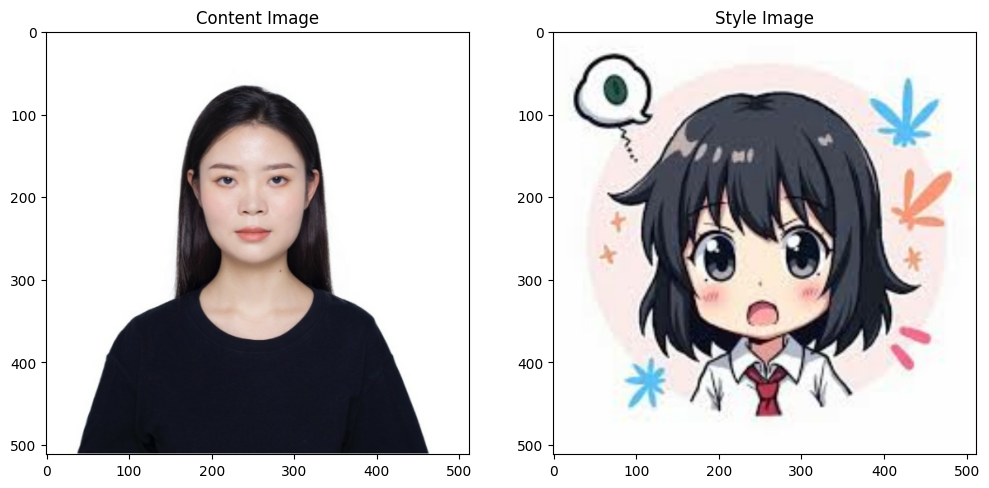

In [24]:
content_image = load_img(content_path)
style_image = load_img(style_path)

plt.subplot(1, 2, 1)
imshow(content_image, 'Content Image')

plt.subplot(1, 2, 2)
imshow(style_image, 'Style Image')

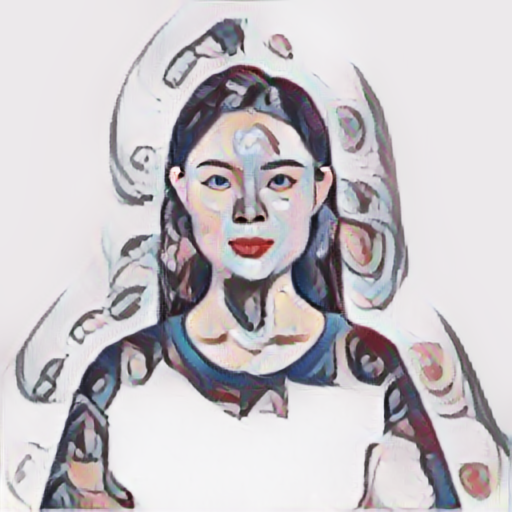

In [25]:
import tensorflow_hub as hub
hub_model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')
stylized_image = hub_model(tf.constant(content_image), tf.constant(style_image))[0]
tensor_to_image(stylized_image)

In [26]:
x = tf.keras.applications.vgg19.preprocess_input(content_image*255)
x = tf.image.resize(x, (224, 224))
vgg = tf.keras.applications.VGG19(include_top=True, weights='imagenet')
prediction_probabilities = vgg(x)
prediction_probabilities.shape

574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step


TensorShape([1, 1000])

In [27]:
predicted_top_5 = tf.keras.applications.vgg19.decode_predictions(prediction_probabilities.numpy())[0]
[(class_name, prob) for (number, class_name, prob) in predicted_top_5]

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


[('jersey', np.float32(0.29438603)),
 ('abaya', np.float32(0.22053353)),
 ('sweatshirt', np.float32(0.0807288)),
 ('bulletproof_vest', np.float32(0.043879353)),
 ('kimono', np.float32(0.042834777))]

In [28]:
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')

print()
for layer in vgg.layers:
  print(layer.name)


input_layer_2
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_conv4
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_conv4
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_conv4
block5_pool


In [29]:
content_layers = ['block5_conv2']

style_layers = ['block1_conv1',
                'block2_conv1',
                'block3_conv1',
                'block4_conv1',
                'block5_conv1']

num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

In [30]:
def vgg_layers(layer_names):
  """ Creates a VGG model that returns a list of intermediate output values."""
  # Load our model. Load pretrained VGG, trained on ImageNet data
  vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
  vgg.trainable = False

  outputs = [vgg.get_layer(name).output for name in layer_names]

  model = tf.keras.Model([vgg.input], outputs)
  return model

In [31]:
style_extractor = vgg_layers(style_layers)
style_outputs = style_extractor(style_image*255)

#Look at the statistics of each layer's output
for name, output in zip(style_layers, style_outputs):
  print(name)
  print("  shape: ", output.numpy().shape)
  print("  min: ", output.numpy().min())
  print("  max: ", output.numpy().max())
  print("  mean: ", output.numpy().mean())
  print()

block1_conv1
  shape:  (1, 512, 512, 64)
  min:  0.0
  max:  876.1021
  mean:  31.265741

block2_conv1
  shape:  (1, 256, 256, 128)
  min:  0.0
  max:  3917.3198
  mean:  180.5799

block3_conv1
  shape:  (1, 128, 128, 256)
  min:  0.0
  max:  11342.79
  mean:  161.62607

block4_conv1
  shape:  (1, 64, 64, 512)
  min:  0.0
  max:  12757.323
  mean:  612.9409

block5_conv1
  shape:  (1, 32, 32, 512)
  min:  0.0
  max:  3360.231
  mean:  48.5243



In [32]:
def gram_matrix(input_tensor):
  result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
  input_shape = tf.shape(input_tensor)
  num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
  return result/(num_locations)

In [33]:
class StyleContentModel(tf.keras.models.Model):
  def __init__(self, style_layers, content_layers):
    super(StyleContentModel, self).__init__()
    self.vgg = vgg_layers(style_layers + content_layers)
    self.style_layers = style_layers
    self.content_layers = content_layers
    self.num_style_layers = len(style_layers)
    self.vgg.trainable = False

  def call(self, inputs):
    "Expects float input in [0,1]"
    inputs = inputs*255.0
    preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)
    outputs = self.vgg(preprocessed_input)
    style_outputs, content_outputs = (outputs[:self.num_style_layers],
                                      outputs[self.num_style_layers:])

    style_outputs = [gram_matrix(style_output)
                     for style_output in style_outputs]

    content_dict = {content_name: value
                    for content_name, value
                    in zip(self.content_layers, content_outputs)}

    style_dict = {style_name: value
                  for style_name, value
                  in zip(self.style_layers, style_outputs)}

    return {'content': content_dict, 'style': style_dict}

In [34]:
extractor = StyleContentModel(style_layers, content_layers)

results = extractor(tf.constant(content_image))

print('Styles:')
for name, output in sorted(results['style'].items()):
  print("  ", name)
  print("    shape: ", output.numpy().shape)
  print("    min: ", output.numpy().min())
  print("    max: ", output.numpy().max())
  print("    mean: ", output.numpy().mean())
  print()

print("Contents:")
for name, output in sorted(results['content'].items()):
  print("  ", name)
  print("    shape: ", output.numpy().shape)
  print("    min: ", output.numpy().min())
  print("    max: ", output.numpy().max())
  print("    mean: ", output.numpy().mean())

Styles:
   block1_conv1
    shape:  (1, 64, 64)
    min:  0.0
    max:  134269.44
    mean:  503.2494

   block2_conv1
    shape:  (1, 128, 128)
    min:  0.0
    max:  230246.28
    mean:  13563.889

   block3_conv1
    shape:  (1, 256, 256)
    min:  0.0
    max:  402780.2
    mean:  11262.472

   block4_conv1
    shape:  (1, 512, 512)
    min:  0.0
    max:  3591112.0
    mean:  146918.33

   block5_conv1
    shape:  (1, 512, 512)
    min:  0.0
    max:  173570.19
    mean:  1034.4698

Contents:
   block5_conv2
    shape:  (1, 32, 32, 512)
    min:  0.0
    max:  1808.9576
    mean:  10.076372


In [35]:
style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']

In [36]:
image = tf.Variable(content_image)

In [37]:
def clip_0_1(image):
  return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0)

In [38]:
opt = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

In [39]:
style_weight=1e-2
content_weight=1e4

In [40]:
def style_content_loss(outputs):
    style_outputs = outputs['style']
    content_outputs = outputs['content']
    style_loss = tf.add_n([tf.reduce_mean((style_outputs[name]-style_targets[name])**2)
                           for name in style_outputs.keys()])
    style_loss *= style_weight / num_style_layers

    content_loss = tf.add_n([tf.reduce_mean((content_outputs[name]-content_targets[name])**2)
                             for name in content_outputs.keys()])
    content_loss *= content_weight / num_content_layers
    loss = style_loss + content_loss
    return loss

In [41]:
@tf.function()
def train_step(image):
  with tf.GradientTape() as tape:
    outputs = extractor(image)
    loss = style_content_loss(outputs)

  grad = tape.gradient(loss, image)
  opt.apply_gradients([(grad, image)])
  image.assign(clip_0_1(image))

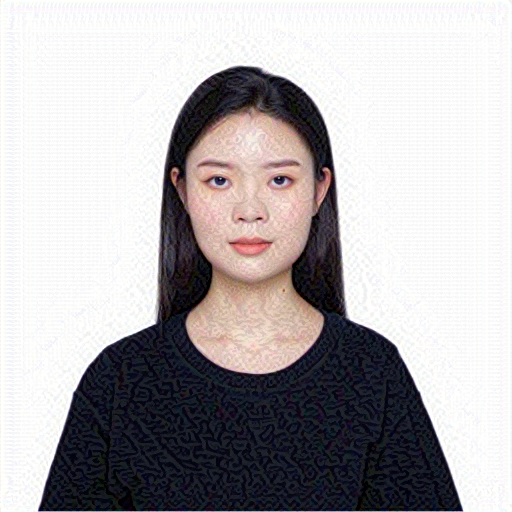

In [42]:
train_step(image)
train_step(image)
train_step(image)
tensor_to_image(image)

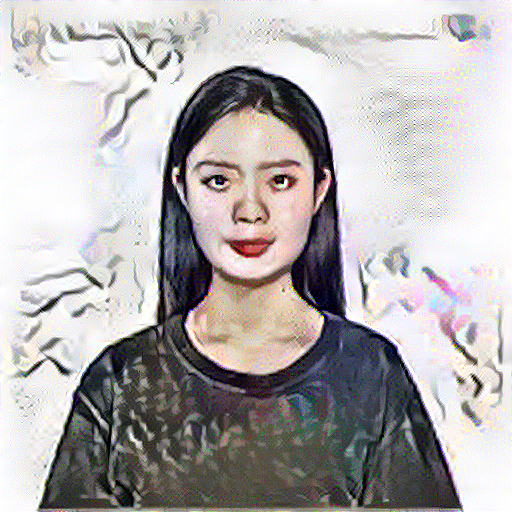

Train step: 1000
Total time: 91.6


In [44]:
# since working, perform a longer optimization

import time
start = time.time()

epochs = 10
steps_per_epoch = 100

step = 0
for n in range(epochs):
  for m in range(steps_per_epoch):
    step += 1
    train_step(image)
    print(".", end='', flush=True)
  display.clear_output(wait=True)
  display.display(tensor_to_image(image))
  print("Train step: {}".format(step))

end = time.time()
print("Total time: {:.1f}".format(end-start))

In [45]:
def high_pass_x_y(image):
  x_var = image[:, :, 1:, :] - image[:, :, :-1, :]
  y_var = image[:, 1:, :, :] - image[:, :-1, :, :]

  return x_var, y_var

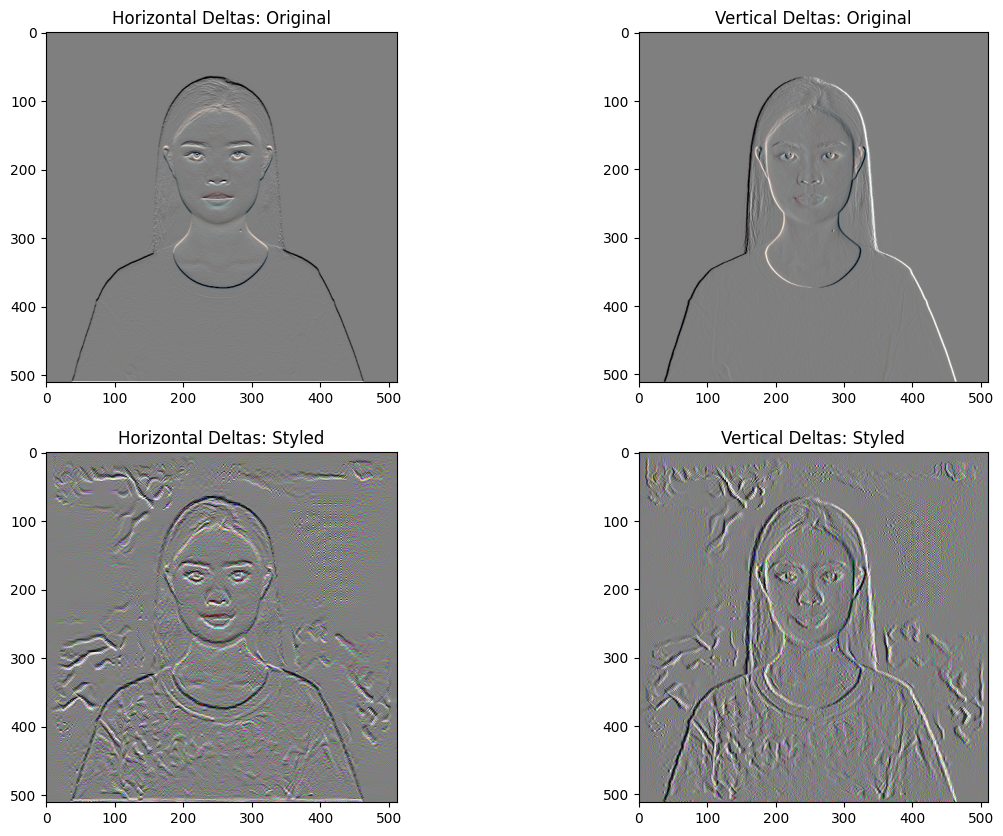

In [46]:
x_deltas, y_deltas = high_pass_x_y(content_image)

plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
imshow(clip_0_1(2*y_deltas+0.5), "Horizontal Deltas: Original")

plt.subplot(2, 2, 2)
imshow(clip_0_1(2*x_deltas+0.5), "Vertical Deltas: Original")

x_deltas, y_deltas = high_pass_x_y(image)

plt.subplot(2, 2, 3)
imshow(clip_0_1(2*y_deltas+0.5), "Horizontal Deltas: Styled")

plt.subplot(2, 2, 4)
imshow(clip_0_1(2*x_deltas+0.5), "Vertical Deltas: Styled")

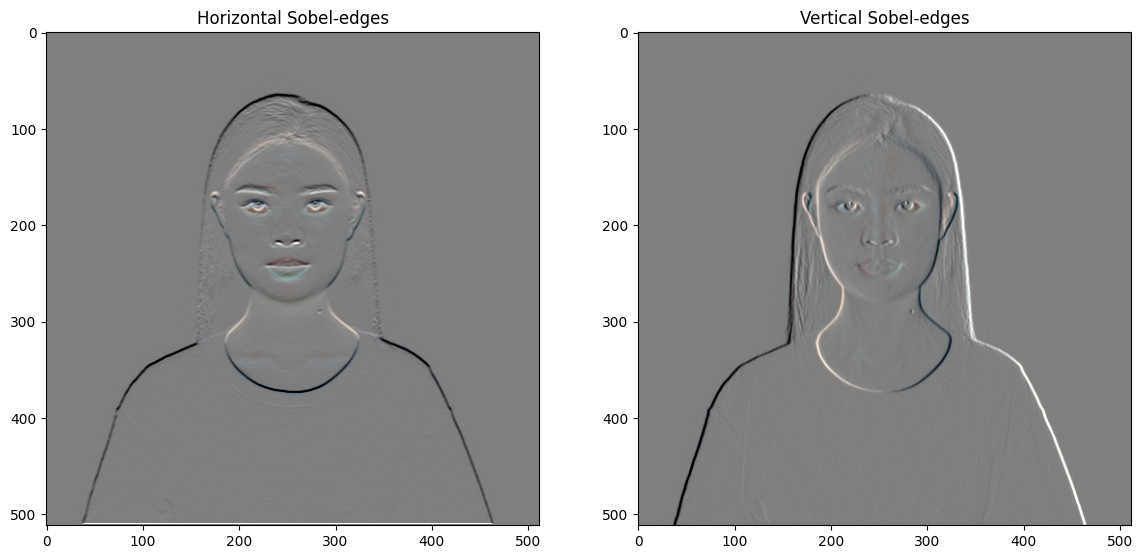

In [47]:
plt.figure(figsize=(14, 10))

sobel = tf.image.sobel_edges(content_image)
plt.subplot(1, 2, 1)
imshow(clip_0_1(sobel[..., 0]/4+0.5), "Horizontal Sobel-edges")
plt.subplot(1, 2, 2)
imshow(clip_0_1(sobel[..., 1]/4+0.5), "Vertical Sobel-edges")

In [48]:
def total_variation_loss(image):
  x_deltas, y_deltas = high_pass_x_y(image)
  return tf.reduce_sum(tf.abs(x_deltas)) + tf.reduce_sum(tf.abs(y_deltas))

In [49]:
total_variation_loss(image).numpy()

np.float32(84326.12)

In [50]:
tf.image.total_variation(image).numpy()

array([84326.12], dtype=float32)

In [51]:
total_variation_weight=30

In [52]:
@tf.function()
def train_step(image):
  with tf.GradientTape() as tape:
    outputs = extractor(image)
    loss = style_content_loss(outputs)
    loss += total_variation_weight*tf.image.total_variation(image)

  grad = tape.gradient(loss, image)
  opt.apply_gradients([(grad, image)])
  image.assign(clip_0_1(image))

In [53]:
opt = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)
image = tf.Variable(content_image)

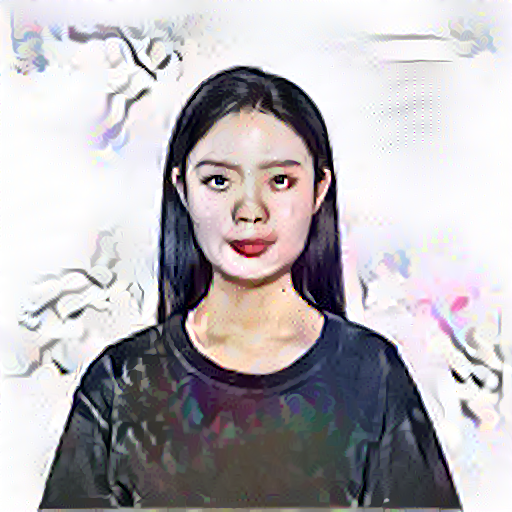

Train step: 1000
Total time: 92.9


In [54]:
import time
start = time.time()

epochs = 10
steps_per_epoch = 100

step = 0
for n in range(epochs):
  for m in range(steps_per_epoch):
    step += 1
    train_step(image)
    print(".", end='', flush=True)
  display.clear_output(wait=True)
  display.display(tensor_to_image(image))
  print("Train step: {}".format(step))

end = time.time()
print("Total time: {:.1f}".format(end-start))

In [55]:
file_name = 'stylized-image.png'
tensor_to_image(image).save(file_name)

try:
  from google.colab import files
  files.download(file_name)
except (ImportError, AttributeError):
  pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>